# ELEN90088 System Optimisation and Machine Learning, 2026

# Exercise 2
## Due date: <u> 23:59, Sunday the 10th May, 2026 </u>




## Submission guidline:

* Answer the exercise questions in this Python notebook itself.
* One submission per group by the due date on LMS. Export your notebook file (.ipynb) as a PDF file. You should submit both ipynb and pdf files.
* For questions involving mathematical derivation, you can either choose to type your solutions using Markdown (Latex), or attach a photo of your hand-written solution in the file.

<br>

## Grading:

## Exercise 2 self grading due date: <u> 23:59, Monday the 18th May, 2026 </u>
### Option 1:
*  By default, you will grade your homeworks with the solution provided by us
* Submission of graded homeworks: solutions will be posted on LMS on 11th May with a grading guideline. You have one week to grade your homeworks. Submit your graded homework (as a PDF file) before 23:59, 18th May. You should note down all marks for individual subquestions, and include your total mark on page 1 of your PDF file. An example will be provided later.
* If you do not submit a graded version by 23:59, 18th May, your homework will be graded by demonstrators.

### Option 2:
* If you wish to have your homeworks graded by demonstrators, please send an email to Muhan (muhan.guan.1@unimelb.edu.au) by the homework due date, and you do not need to submit a graded version. If you choose this path and submit a graded version, we will still mark your homework instead of using your self-graded results.





## Submission guideline:

* One submission per group by the due date on LMS.
* Answer the exercise questions in this Python notebook itself.
* Export your notebook file (.ipynb) as a PDF file, on which we give marks and comments. This means that each group should submit two versions of the exercise report (.ipynb file and PDF).
* Demonstrators will conduct a brief oral assessment for selected groups in subsequent workshop. Details will be announced on LMS.
* Regarding the use of LLM and other generative AI tools: refer to information in the introductory slides.





## Question 1 (Bayesian infrence, MLE and MAP) (Mark:  5 + 7 + 2 + 6 = 20 points)
In this question, we'll explore Bayesian infrence, MLE and MAP.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
plt.rcParams["animation.html"] = "jshtml"
from scipy.stats import bernoulli, beta

**A lucky find**

On the way to class, you discover an unusual coin on the ground.

<img src="https://upload.wikimedia.org/wikipedia/commons/6/68/1_2_penny_Middlesex_DukeYork_1795_1ar85_%288737903267%29.jpg" alt="Coin" width="350"/>

As a dedicated student in SOML, you're interested in determining whether the coin is _biased_.
More specifically, you want to estimate the probability $\theta$ that the coin will land heads-up when you toss it. If $\theta \approx \frac{1}{2}$ then we say that the coin is _unbiased_ (or fair).

You can use the function below to simulate a coin toss: it returns `1` for heads and `0` for tails.

In [16]:
def toss_coin():
    if bernoulli.rvs(p = (int.from_bytes("coin".encode(), 'little') % 10000)/10000):
        return 1
    return 0

In [17]:
(int.from_bytes("coin".encode(), 'little') % 10000)/10000

0.3555

In [18]:
x1 = toss_coin()
print(x1)

1


**Prior belief**

Before you even toss the coin, you notice that the heads side appears to have more mass.
Thus, your _prior belief_ is that $\theta$ is slightly biased away from $\frac{1}{2}$ towards 0—i.e. you expect tails are more likely.

To quantify this prior belief, we assume that the prior distribution for $\theta$ is $\mathrm{Beta}(a,b)$, for some choice of the hyperparameters $a, b > 0$.
(See [link](https://en.wikipedia.org/wiki/Beta_distribution) for info about the Beta distribution.)
The prior probability density function for $\theta$ is therefore given by:

$$ p(\theta) = \frac{1}{B(a,b)} \theta^{a-1} (1 - \theta)^{b-1} $$

where $B(a,b)$ is a special function called the _Beta function_.

Select appropriate values for $a$ and $b$ by looking at the plot of $p(\theta)$ below.

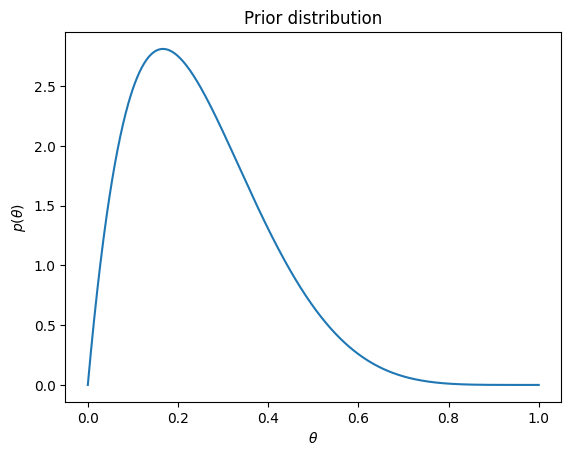

In [19]:
a = 2 # fill in
b = 6 # fill in
theta = np.linspace(0, 1, 1001)
plt.plot(theta, beta.pdf(theta, a, b))
plt.title('Prior distribution')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$p(\theta)$')
plt.show()

**Posterior updates:** Now toss the coin once and denote the outcome by $x_1$.

In [27]:
x1 = toss_coin()
print(x1)

1


We can update our belief about $\theta$, based on this new evidence $x_1$.
To do this we apply Bayes' rule to compute the posterior for $\theta$:

$$ p(\theta | x_1) = \frac{p(x_1 | \theta) \, p(\theta)}{p(x_1)} \propto p(x_1 | \theta) \, p(\theta)$$

where $p(\theta)$ is the prior given above and

$$ p(x_1 | \theta) = \theta^{x_1} (1 - \theta)^{1 - x_1} $$

is the likelihood.

\[Note: We always assume the tosses are independent, otherwise the likelihood for $x_2$ would depend on $x_1$.\]
***


### Part A: Mathematical Derivation

Toss the coin a second time, denoting the outcome by $x_2$.

In [30]:
x2 = toss_coin()
print(x2)

0


Again, we want to update our belief about $\theta$ based on the new information $x_2$.
We take the previous posterior $p(\theta|x_1)$ as the new prior and apply Bayes' rule:

$$ p(\theta | x_1, x_2) \propto p(x_2 | \theta) p(\theta | x_1)$$



***
Show that for $n$ coin tosses, the posterior is $\theta | x_1, \ldots, x_n \sim \operatorname{Beta}[n_H + a, n - n_H + b]$ where $n_H = \sum_{i = 1}^{n} x_i$ is the number of heads observed.

***

#### Answer to Q1 Part A:
Since $\theta \sim \mathrm{Beta}(a,b)$

$$
p(\theta) \propto \theta^{a-1}(1-\theta)^{b-1}
$$

For each coin toss, $x_i \mid \theta \sim \mathrm{Bernoulli}(\theta)$

$$
p(x_i \mid \theta)=\theta^{x_i}(1-\theta)^{1-x_i}
$$

Since the tosses are independent, the likelihood for \(n\) observations is

$$
\begin{aligned}
p(x_1,\dots,x_n \mid \theta)
&= p(x_1 \mid \theta)p(x_2 \mid \theta)\dots p(x_n \mid \theta) \\
&= \prod_{i=1}^{n}\theta^{x_i}(1-\theta)^{1-x_i} \\
&= \theta^{\sum_{i=1}^{n}x_i}(1-\theta)^{\sum_{i=1}^{n}(1-x_i)}
\end{aligned}
$$

Let
$$
n_H=\sum_{i=1}^{n}x_i 
$$

$$ 
p(x_1,\dots,x_n \mid \theta) = \theta^{n_H}(1-\theta)^{n-n_H}
$$

Applying Bayes' rule

$$
\begin{aligned}
p(\theta \mid x_1,\dots,x_n)
&\propto p(x_1,\dots,x_n \mid \theta)p(\theta) \\
&= \theta^{n_H}(1-\theta)^{n-n_H}\theta^{a-1}(1-\theta)^{b-1} \\
&= \theta^{n_H+a-1}(1-\theta)^{n-n_H+b-1}
\end{aligned}
$$

This has the same form as a Beta distribution. 

Hence,
$$
\theta \mid x_1,\dots,x_n \sim \mathrm{Beta}(n_H+a,\ n-n_H+b)
$$


### Part B:  Mathematical Derivation for MAP estimator and MLE estimator

The posterior $\theta|x_1, \ldots, x_n$ contains all the information we know about $\theta$ after observing $n$ coin tosses.
One way of obtaining a point estimate of $\theta$ from the posterior, is to take the value with the maximum a posteriori probability (MAP):
$$
\begin{align}
    \hat{\theta}_\mathrm{MAP} &= \arg \max_{\theta} p(\theta|x_1, \ldots, x_n) \tag{1}
\end{align}
$$

In general, the MAP estimator gives a different result to the maximum likelihood estimator (MLE) for $\theta$:
$$
\begin{align}
    \hat{\theta}_\mathrm{MLE} &=\arg \max_{\theta} p(x_1, \ldots, x_n|\theta) \tag{2}\\
\end{align}
$$

***
 How would you derive the above results for $\hat{\theta}_\mathrm{MAP}$ and  $\hat{\theta}_\mathrm{MLE}$? Setup the equations for solving $\hat{\theta}_\mathrm{MAP}$ and  $\hat{\theta}_\mathrm{MLE}$ and then solve them.


#### Answer to Q1 Part B:

##### MAP estimator:

$$
p(\theta \mid x_1,\dots,x_n) \propto \theta^{n_H+a-1}(1-\theta)^{n-n_H+b-1}
$$

The MAP estimator is defined as

$$
\begin{aligned}
\hat{\theta}_{\mathrm{MAP}}
&= \arg\max_{\theta} p(\theta \mid x_1,\dots,x_n) \\
&= \arg\max_{\theta} \left[ \theta^{n_H+a-1}(1-\theta)^{n-n_H+b-1} \right]
\end{aligned}
$$

Define
$$
\begin{aligned}
\ell_{\mathrm{MAP}}(\theta)
&= \log \left[\theta^{n_H+a-1}(1-\theta)^{n-n_H+b-1}\right] \\
&= (n_H+a-1)\log\theta + (n-n_H+b-1)\log(1-\theta)
\end{aligned}
$$

Thus,

$$
\hat{\theta}_{\mathrm{MAP}} = \arg\max_{\theta} \ell_{\mathrm{MAP}}(\theta)
$$

$$
\frac{d\ell_{\mathrm{MAP}}}{d\theta} = \frac{n_H+a-1}{\theta} - \frac{n-n_H+b-1}{1-\theta}
$$

Set the derivative equal to zero:

$$
\frac{n_H+a-1}{\theta} = \frac{n-n_H+b-1}{1-\theta}
$$

$$
\hat{\theta}_{\mathrm{MAP}} = \frac{n_H+a-1}{n+a+b-2}
$$

##### MLE estimator:

$$
p(x_1,\dots,x_n \mid \theta) = \theta^{n_H}(1-\theta)^{n-n_H}
$$

The MLE estimator is defined as

$$
\begin{aligned}
\hat{\theta}_{\mathrm{MLE}}
&= \arg\max_{\theta} p(x_1,\dots,x_n \mid \theta) \\
&= \arg\max_{\theta} \left[\theta^{n_H}(1-\theta)^{n-n_H}\right]
\end{aligned}
$$

Similarly, define

$$
\begin{aligned}
\ell_{\mathrm{MLE}}(\theta)
&= \log \left[p(x_1,\dots,x_n \mid \theta)\right] \\
&= \log \left[\theta^{n_H}(1-\theta)^{n-n_H}\right] \\
&= n_H\log\theta + (n-n_H)\log(1-\theta)
\end{aligned}
$$


$$
\frac{d\ell_{\mathrm{MLE}}}{d\theta} = \frac{n_H}{\theta} - \frac{n-n_H}{1-\theta}
$$

Set the derivative equal to zero:

$$
\frac{n_H}{\theta} = \frac{n-n_H}{1-\theta}
$$

$$
\hat{\theta}_{\mathrm{MLE}} = \frac{n_H}{n}
$$

Hence, the final results are

$$
\boxed{ 
    \hat{\theta}_{\mathrm{MAP}} = \frac{n_H+a-1}{n+a+b-2} 
}
$$

and

$$
\boxed{
    \hat{\theta}_{\mathrm{MLE}} = \frac{n_H}{n}
}
$$

### Part C: Programming
Let's now toss the coin an additional 100 times (so that $n = 102$) using the given function ``toss_coin()``. After each toss, compute and record $\hat{\theta}_\mathrm{MLE}$ and $\hat{\theta}_\mathrm{MAP}$ (using the expresssion you solved from Part B). Plot both estimates them as two lines on the same graph. To compute $\hat{\theta}_\mathrm{MAP}$, we set the parameters of the beta prior distribution as $a=2$ and $b=6$.

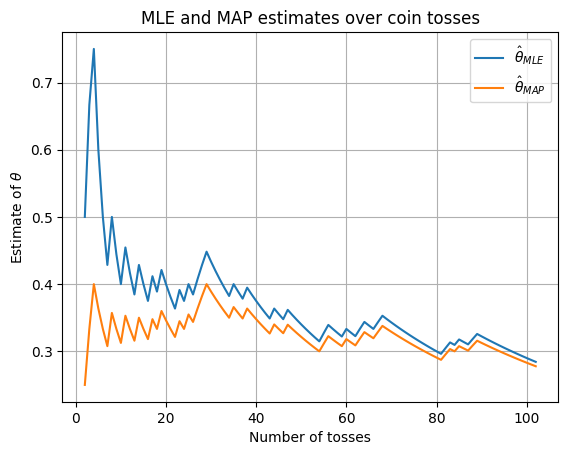

In [31]:
a = 2
b = 6

# Store all observations
xs = [x1, x2]

# Store estimates
theta_mle_list = []
theta_map_list = []

# First compute estimates using the first two tosses
n = len(xs)
n_H = sum(xs)

theta_mle = n_H / n
theta_map = (n_H + a - 1) / (n + a + b - 2)

theta_mle_list.append(theta_mle)
theta_map_list.append(theta_map)

# Toss the coin an additional 100 times
for _ in range(100):
    x_new = toss_coin()
    xs.append(x_new)

    n = len(xs)
    n_H = sum(xs)

    theta_mle = n_H / n
    theta_map = (n_H + a - 1) / (n + a + b - 2)

    theta_mle_list.append(theta_mle)
    theta_map_list.append(theta_map)

# Plot
plt.plot(range(2, 103), theta_mle_list, label=r'$\hat{\theta}_{MLE}$')
plt.plot(range(2, 103), theta_map_list, label=r'$\hat{\theta}_{MAP}$')

plt.xlabel('Number of tosses')
plt.ylabel(r'Estimate of $\theta$')
plt.title('MLE and MAP estimates over coin tosses')
plt.legend()
plt.grid(True)
plt.show()

### Part D: Online Learning for Coin Toss Prediction

In this task, you will consider an online learning problem for predicting the outcomes of a coin toss sequence.

Assume a sequence of coin toss outcomes
$$
x_1, x_2, \dots, x_n \sim P_\theta,
$$
where $x_i \in \{0,1\}$ and $\theta$ is the probability of observing a head $(x_i=1)$. Again, the parameter $\theta$ is unkown, and you only observe samples from this distribution.

You need **predict** the outcome at each time step $i$ given seen results of previous $(i-1)$ steps.
The reward at time $i$ is defined as:
$$
r_i =
\begin{cases}
+1, & \text{correct guess} \\
-1, & \text{wrong guess}
\end{cases}
$$



1) Develop a Maximum Likelihood Estimator based strategy that maximizes the total rewards:
$$
\max \sum_{i=1}^{n} r_i.
$$

**Data Generation**：Use the function ```toss_coin``` to generate one particular sample of 1000 coin tosses.

Note: Updating $\hat \theta$ by ML estimator, predict $\hat x_i$ as $1$ if $\hat \theta\ge 0.5$, otherwise predict it as zero. Set the first prediction as $1$ before seeing any toss results.





To assess the performance of your strategy, you compare the rewards of your strategy to the case when the parameter $\theta$ is known, and the *optimal* prediction rule is used.

2) Specifically, now you know that the true parameter $\theta$ is $0.3555$. Let $r_i^*$ denote the reward at time $i$ using this optimal prediction rule.

We can define the *normalized regret* of the strategy as
$$
R_n: =  \frac{1}{n}(\sum_{i=1}^{n} r_i^* - \sum_{i=1}^n r_i)
$$

namely the difference between the optimal reward and the reward obtained by our strategy. It signifies the cost of not knowing the true parameter $\theta$.

What is the optimal prediction rule that maximizes the total *expected reward*? Calculate the normalized regret of your strategy given this particular sequence.



3) Generate sequences with various lengths (from $n=10$ to $n=1000$) using the same random seed as in the previous question. Plot $R_n$ against $n$. Comment on your observations.





**An Important Note**: This is an online prediction problem, not a batch prediction problem. Here you use this sequence with 100 tosses to design your strategy and verify your total rewards. However, the prediction must be made sequentially. To be specific, at time step $i$, you are only allowed to use the outcomes from the previous $i-1$ tosses, and you are not allowed to use the outcome of the current (and future) toss before making your prediction.

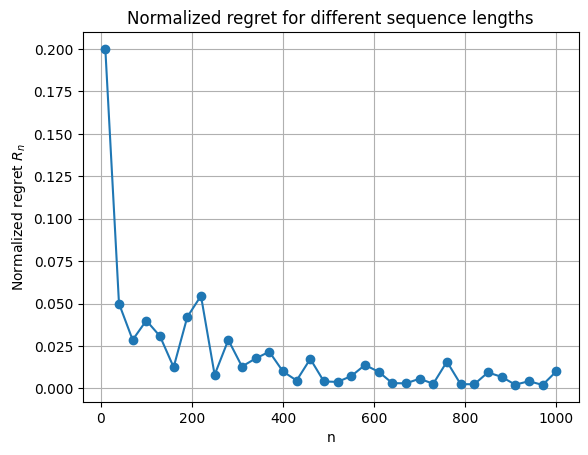

In [36]:
np.random.seed(202690088)# keep it

theta_true = 0.3555
n_values = range(10, 1001, 30)
regrets = []

for n in n_values:
    sequence = [toss_coin() for _ in range(n)]

    # MLE-based online strategy
    predictions = []
    rewards = []
    n_H = 0
    n_seen = 0
    for i, x in enumerate(sequence):
        if i == 0:
            x_hat = 1
        else:
            theta_hat_mle = n_H / n_seen
            if theta_hat_mle >= 0.5:
                x_hat = 1
            else:
                x_hat = 0

        predictions.append(x_hat)
        if x_hat == x:
            rewards.append(1)
        else:
            rewards.append(-1)

        # update after observing current toss
        n_H += x
        n_seen += 1

    # Optimal strategy when theta is known
    optimal_predictions = []
    optimal_rewards = []
    for x in sequence:
        if theta_true >= 0.5:
            x_hat_star = 1
        else:
            x_hat_star = 0

        optimal_predictions.append(x_hat_star)
        if x_hat_star == x:
            optimal_rewards.append(1)
        else:
            optimal_rewards.append(-1)

    # Normalized regret
    R_n = (sum(optimal_rewards) - sum(rewards)) / n
    regrets.append(R_n)


plt.plot(n_values, regrets, marker='o')
plt.xlabel('n')
plt.ylabel(r'Normalized regret $R_n$')
plt.title('Normalized regret for different sequence lengths')
plt.grid(True)
plt.show()


# print("Total reward of MLE strategy:", sum(rewards))
# print("Total reward of optimal strategy:", sum(optimal_rewards))
# print("Normalized regret R_n:", R_n)

Observation: At small $n$: $R_n$ is large, as $n$ increases: $R_n\to0$. Eventually $R_n$ becomes very close to $0$. This means *asymptotically*, our strategy (without the knowledge of the true parameter) will incur the same average loss as the optimal strategy.

(1 mark for correct plot, 1 mark for the correct observation)

## Question 2: K-means Clustering (Marks: 10 + 10 = 20 Points)


### Example: Clustering and Gaussian Mixtures
Unsupervised learning is all about data. We will use first the two circles dataset to practice a little bit and digest some of the fundemental concepts. Since two circles data inherently has two clusters (each circles as a cluster), we can use this as a [ground truth](https://en.wikipedia.org/wiki/Ground_truth). In most real problems, we don't have this luxury of having the ground truth at hand! This dataset can be directly available from the sklearn library, which is shown as follows.

**Note:** This two circles dataset is available from [*Scikit Learn*](https://scikit-learn.org/stable/user_guide.html). Hint: check [*cluster*](https://scikit-learn.org/stable/api/sklearn.cluster.html#), [*datasets*](https://scikit-learn.org/stable/api/sklearn.datasets.html), [*mixture*](https://scikit-learn.org/stable/api/sklearn.mixture.html#), [*utils*](https://scikit-learn.org/stable/api/sklearn.utils.html), [*decomposition*](https://scikit-learn.org/stable/api/sklearn.decomposition.html), and [*metrics*](https://scikit-learn.org/stable/api/sklearn.metrics.html).

Scikit Learn does not have its own global random state, uses the [numpy random state](https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.random.seed.html#numpy.random.seed) instead. See the code below.

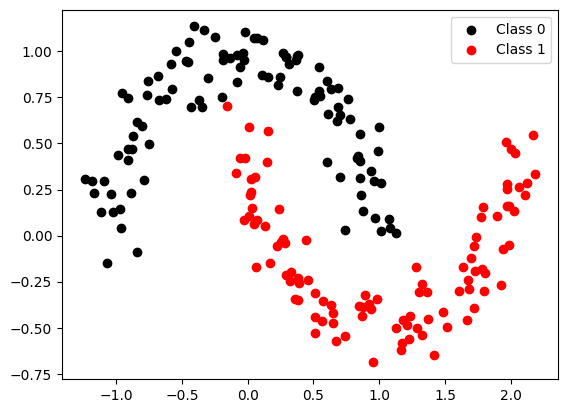

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

from sklearn import cluster, datasets, mixture
from sklearn.cluster import KMeans
from sklearn.utils import shuffle
from sklearn import decomposition
from sklearn.mixture import GaussianMixture
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt

#use this seed in your solution
np.random.seed(16543677)


# Generate concentric circles
# factor determines the distance between the inner and outer circles
X, y = noisy_moons = datasets.make_moons(n_samples=200, noise=0.1)

# Plot data
plt.figure()
plt.scatter(X[y==0, 0], X[y==0, 1], color='black', label='Class 0')
plt.scatter(X[y==1, 0], X[y==1, 1], color='red', label='Class 1')
plt.legend()
plt.show()


### Part A: K-means Clustering (10 points)
**Questions:**
1. Use sklearn's k-means clustering algorithm to divide the data given above ($X$) into two clusters. Plot the result and show the cluster centres that you found.
2. Experiment with different starting points (`init='random'`) and number of clusters, e.g. 3, 4, 5. Plot the results.
3. Write your observations and interpret them using your theoretical knowledge from lectures and books.

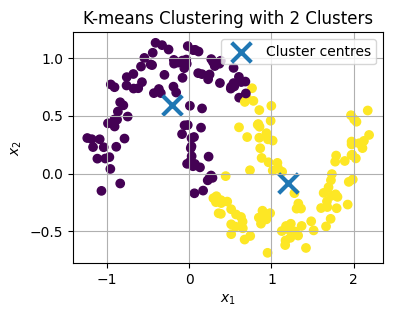

In [2]:
# K-means clustering with 2 clusters
kmeans_2 = KMeans(n_clusters=2, init='random', random_state=16543677, n_init=10)
kmeans_2.fit(X)

labels_2 = kmeans_2.labels_
centers_2 = kmeans_2.cluster_centers_

# Plot result
plt.figure(figsize=(4, 3))
plt.scatter(X[:, 0], X[:, 1], c=labels_2)
plt.scatter(centers_2[:, 0], centers_2[:, 1], marker='x', s=200, linewidths=3, label='Cluster centres')
plt.title('K-means Clustering with 2 Clusters')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.grid(True)
plt.show()

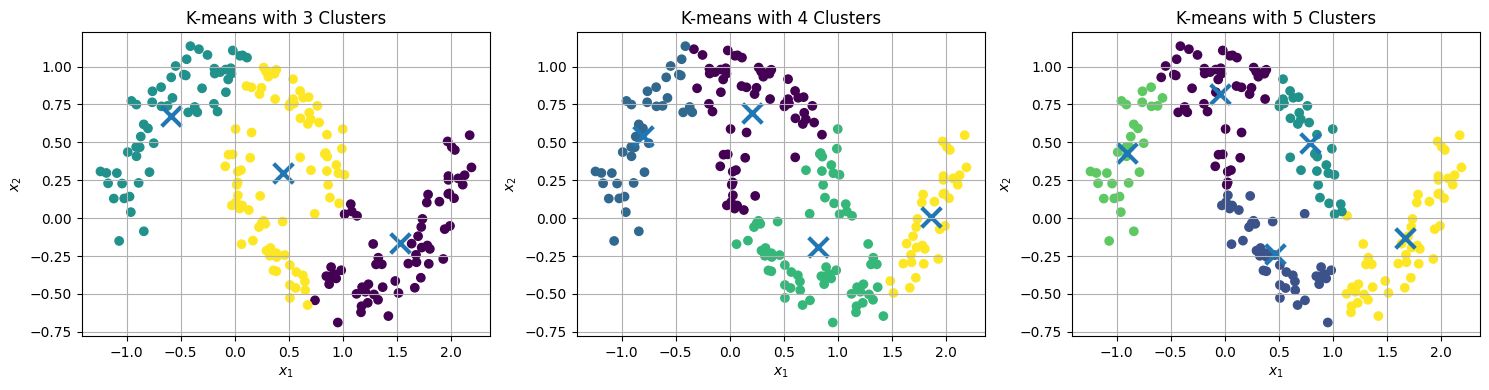

In [3]:
k_values = [3, 4, 5]

plt.figure(figsize=(15, 4))

for idx, k in enumerate(k_values):
    kmeans = KMeans(n_clusters=k, init='random', random_state=16543677, n_init=10)
    kmeans.fit(X)

    labels = kmeans.labels_
    centers = kmeans.cluster_centers_

    plt.subplot(1, 3, idx + 1)
    plt.scatter(X[:, 0], X[:, 1], c=labels)
    plt.scatter(centers[:, 0], centers[:, 1], marker='x', s=200, linewidths=3)
    plt.title(f'K-means with {k} Clusters')
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    plt.grid(True)

plt.tight_layout()
plt.show()

#### Answer to Q2 Part A:

K-means clustering was first applied with \(K=2\), since the dataset contains two true classes.

From the plot, K-means divides the data into two clusters based on Euclidean distance to the cluster centres. The cluster centres are shown using cross markers. However, the result does not perfectly match the two-moon structure of the data.

This happens because K-means assumes that clusters are roughly spherical or convex around their centres. In this dataset, the two classes have non-convex crescent shapes. Therefore, although there are two natural classes, K-means tends to split the data using distance-based regions rather than following the curved shape of each moon.

When different numbers of clusters are used, such as \(K=3,4,5\), K-means further divides the two moons into smaller local groups. Increasing \(K\) can reduce the within-cluster distance, but the resulting clusters no longer correspond to the true two classes. Instead, each moon is broken into several smaller parts.

Therefore, K-means is not very suitable for this dataset, because its distance-to-centre assumption does not match the non-convex geometry of the two-moon data.

### Part B: GMMs as Density Estimators (10 points)
**Questions:**
1. Now use a Gaussian Mixture Model (GMM) for clustering the same two moon data. Try two clusters and plot your results. GMMs also provides you probabilities (of a sample belonging to a cluster). Print those of a few samples using [*pandas.DataFrame*](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html).
2. Increase the number of components of your GMM model, e.g., 3, 4, and 5. Plot the results.
3. Use a metric to choose the number of components in a principled way. *Hint: check [BIC](https://en.wikipedia.org/wiki/Bayesian_information_criterion) or [AIC](https://en.wikipedia.org/wiki/Akaike_information_criterion)*. Plot the result of the optimal number of components and print the probabilities of some samples.
4. Write your observations and interpret them using your theoretical knowledge from lectures and books.

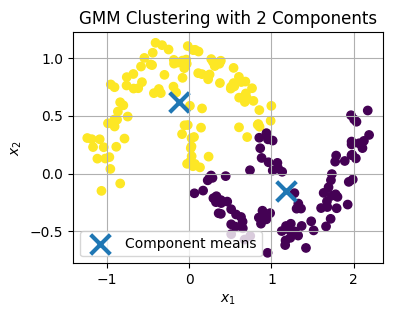

,Component 0 probability,Component 1 probability
0,0.822444,0.177556
1,0.000067,0.999933
2,0.978897,0.021103
3,0.999896,0.000104
4,0.012181,0.987819


In [4]:
import pandas as pd

# GMM with 2 components
gmm_2 = GaussianMixture(
    n_components=2,
    random_state=16543677
)

gmm_2.fit(X)

labels_gmm_2 = gmm_2.predict(X)
probs_gmm_2 = gmm_2.predict_proba(X)
centers_gmm_2 = gmm_2.means_

plt.figure(figsize=(4, 3))
plt.scatter(X[:, 0], X[:, 1], c=labels_gmm_2)
plt.scatter(
    centers_gmm_2[:, 0],
    centers_gmm_2[:, 1],
    marker='x',
    s=200,
    linewidths=3,
    label='Component means'
)

plt.title('GMM Clustering with 2 Components')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.grid(True)
plt.show()

prob_df = pd.DataFrame(
    probs_gmm_2[:5],
    columns=['Component 0 probability', 'Component 1 probability']
)

prob_df

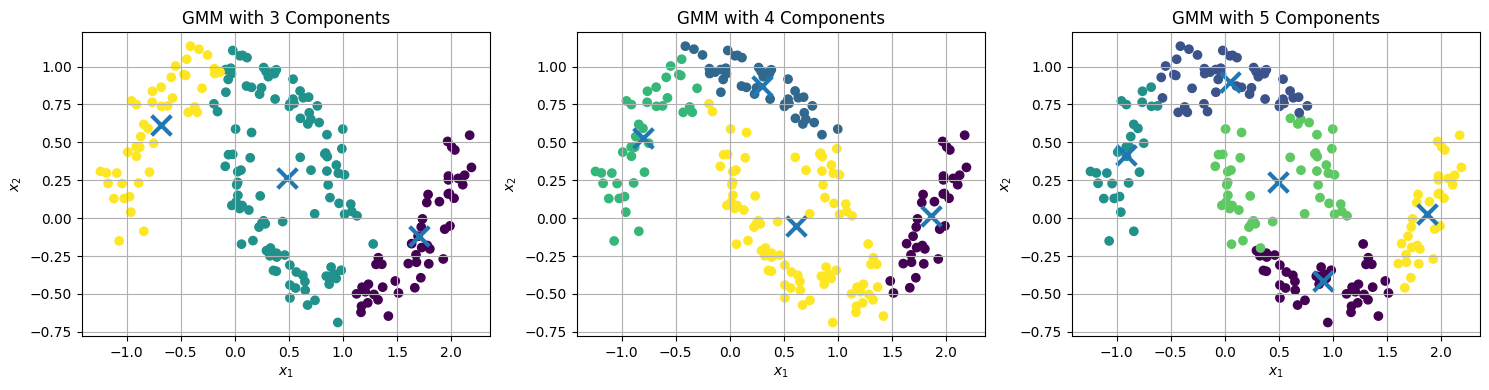

In [5]:
component_values = [3, 4, 5]

plt.figure(figsize=(15, 4))

for idx, k in enumerate(component_values):
    gmm = GaussianMixture(
        n_components=k,
        random_state=16543677
    )

    gmm.fit(X)

    labels = gmm.predict(X)
    centers = gmm.means_

    plt.subplot(1, 3, idx + 1)
    plt.scatter(X[:, 0], X[:, 1], c=labels)
    plt.scatter(
        centers[:, 0],
        centers[:, 1],
        marker='x',
        s=200,
        linewidths=3
    )

    plt.title(f'GMM with {k} Components')
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    plt.grid(True)

plt.tight_layout()
plt.show()

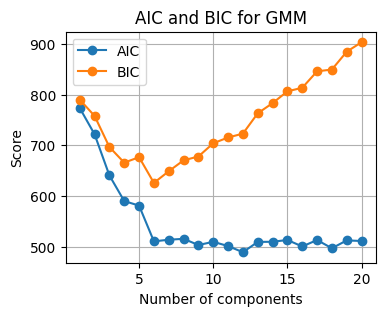

In [6]:
component_range = range(1, 21)

aic_values = []
bic_values = []

for k in component_range:
    gmm = GaussianMixture(
        n_components=k,
        random_state=16543677
    )

    gmm.fit(X)

    aic_values.append(gmm.aic(X))
    bic_values.append(gmm.bic(X))

plt.figure(figsize=(4, 3))
plt.plot(component_range, aic_values, marker='o', label='AIC')
plt.plot(component_range, bic_values, marker='o', label='BIC')
plt.xlabel('Number of components')
plt.ylabel('Score')
plt.title('AIC and BIC for GMM')
plt.legend()
plt.grid(True)
plt.show()

Optimal number of components based on BIC: 6


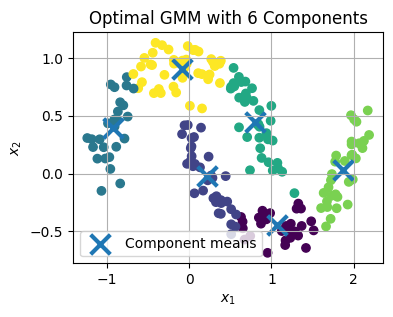

,Component 0 probability,Component 1 probability,Component 2 probability,Component 3 probability,Component 4 probability,Component 5 probability
0,8.956037e-11,1.384622e-20,2.902621e-52,9.999998e-01,5.730037e-21,1.708316e-07
1,1.455782e-39,2.843943e-13,3.420813e-15,1.257620e-01,4.130339e-91,8.742380e-01
2,3.570849e-02,9.642915e-01,5.234866e-36,2.929052e-10,2.124156e-34,1.181621e-16
3,2.603246e-05,5.980220e-58,2.374722e-122,1.413642e-11,9.999740e-01,3.798189e-20
4,3.543244e-24,1.483656e-15,2.718360e-28,9.731651e-01,4.916290e-54,2.683489e-02


In [8]:
# Optimal number based on BIC
optimal_k = component_range[np.argmin(bic_values)]
print("Optimal number of components based on BIC:", optimal_k)

gmm_optimal = GaussianMixture(
    n_components=optimal_k,
    random_state=16543677
)

gmm_optimal.fit(X)

labels_optimal = gmm_optimal.predict(X)
probs_optimal = gmm_optimal.predict_proba(X)
centers_optimal = gmm_optimal.means_
plt.figure(figsize=(4, 3))
plt.scatter(X[:, 0], X[:, 1], c=labels_optimal)
plt.scatter(
    centers_optimal[:, 0],
    centers_optimal[:, 1],
    marker='x',
    s=200,
    linewidths=3,
    label='Component means'
)

plt.title(f'Optimal GMM with {optimal_k} Components')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.grid(True)
plt.show()

prob_optimal_df = pd.DataFrame(
    probs_optimal[:5],
    columns=[f'Component {i} probability' for i in range(optimal_k)]
)

prob_optimal_df

Optimal number of components based on AIC: 12


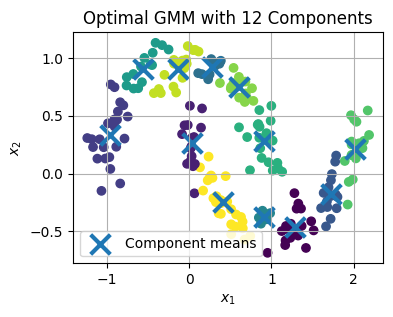

,Component 0 probability,Component 1 probability,Component 2 probability,Component 3 probability,Component 4 probability,Component 5 probability,Component 6 probability,Component 7 probability,Component 8 probability,Component 9 probability,Component 10 probability,Component 11 probability
0,1.364395e-11,1.104128e-46,1.299079e-55,5.369877e-50,1.533090e-144,1.681801e-88,5.363059e-155,9.999997e-01,1.504155e-43,3.215096e-07,2.460244e-84,7.585469e-28
1,1.463664e-58,4.025727e-07,4.632224e-20,4.586948e-216,9.935391e-01,0.000000e+00,1.275984e-21,5.627115e-06,4.288865e-152,6.345647e-03,1.092403e-04,4.790810e-26
2,6.928448e-13,1.041686e-10,1.327091e-35,1.276183e-123,7.040642e-204,2.185027e-37,7.786604e-155,5.499467e-08,1.032964e-89,2.646157e-49,2.011126e-88,9.999999e-01
3,3.356658e-06,5.185720e-175,1.197191e-125,1.706119e-03,0.000000e+00,1.247967e-123,0.000000e+00,1.710971e-13,9.982905e-01,5.361336e-35,5.868168e-250,5.300588e-69
4,8.741438e-33,1.744126e-17,1.816477e-32,9.963817e-129,4.972336e-27,1.427549e-284,6.929921e-65,5.780832e-02,5.683184e-96,9.421917e-01,1.333383e-26,2.416923e-25


In [9]:
# Optimal number based on AIC
optimal_k = component_range[np.argmin(aic_values)]
print("Optimal number of components based on AIC:", optimal_k)

gmm_optimal = GaussianMixture(
    n_components=optimal_k,
    random_state=16543677
)

gmm_optimal.fit(X)

labels_optimal = gmm_optimal.predict(X)
probs_optimal = gmm_optimal.predict_proba(X)
centers_optimal = gmm_optimal.means_
plt.figure(figsize=(4, 3))
plt.scatter(X[:, 0], X[:, 1], c=labels_optimal)
plt.scatter(
    centers_optimal[:, 0],
    centers_optimal[:, 1],
    marker='x',
    s=200,
    linewidths=3,
    label='Component means'
)

plt.title(f'Optimal GMM with {optimal_k} Components')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.grid(True)
plt.show()

prob_optimal_df = pd.DataFrame(
    probs_optimal[:5],
    columns=[f'Component {i} probability' for i in range(optimal_k)]
)

prob_optimal_df

#### Answer to Q2 Part B:

A Gaussian Mixture Model was first applied with 2 components, since the original two-moon dataset contains two true classes.

Unlike K-means, GMM models the data as a mixture of Gaussian distributions. Each component has its own mean and covariance, and each sample is assigned a probability of belonging to each component. Therefore, GMM gives soft cluster assignments rather than only hard labels.

From the results, GMM is more flexible than K-means because the components can have elliptical shapes instead of only distance-based regions around cluster centres. However, GMM still does not perfectly separate the two moons. This is because each Gaussian component is still a local elliptical distribution, while the two-moon dataset has a non-convex curved structure.

For \(K=3,4,5\), the model divides the moons into several local Gaussian components. However, near the inner region where the two moons are close to each other, points from different moons can still be assigned to the same component. This shows that GMM is mainly modelling local density regions rather than directly recovering the true moon-shaped classes.

Using BIC, the optimal number of components is \(K=6\). Using AIC, the optimal number of components is \(K=12\). The AIC result uses more components because AIC penalizes model complexity less strongly than BIC. With more components, the GMM can approximate the curved shape better, but the components still represent local Gaussian pieces rather than the two original classes.

Overall, GMM can model the density of the two-moon data better than K-means, especially when more components are used. However, it is still not ideal for directly separating the two non-convex moon-shaped classes, because Gaussian components are not designed to represent an entire curved cluster.

## Question 3: Neural Networks (Marks: 20 Points)

Classification is a supervised learning technique where we want to predict the class or label of new data points based on a training dataset that has labels already. In this question, we will implementation a DNN classification with PyTorch.

**Example:**

PyTorch is an open-source machine learning framework, which is widely used for building and training lightweight deep learning models. For those who are new to PyTorch or willing to delve into more technical content, it is highly recommended to explore the official [tutorials](https://pytorch.org/tutorials/) and [docs](https://pytorch.org/docs/stable/index.html).

We will exhibit how to build a neural network with PyTorch. The following codes provide a framework to define a DNN. For more details and advanced tricks, here are some helpful resources
<a name="cite_ref-1"></a>[<sup>[1]</sup>](#cite_note-1)<a name="cite_ref-2"></a>[<sup>[2]</sup>](#cite_note-2)<a name="cite_ref-3"></a>[<sup>[3]</sup>](#cite_note-3).

<a name="cite_note-1"></a> [<sup>[1]</sup>](#cite_ref-1) [Build a neural network](https://pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html).

<a name="cite_note-2"></a> [<sup>[2]</sup>](#cite_ref-2) [Use CNN to classify digit images](https://pytorch.org/tutorials/beginner/blitz/neural_networks_tutorial.html).

<a name="cite_note-3"></a> [<sup>[3]</sup>](#cite_ref-3) [Useful APIs](https://pytorch.org/docs/stable/nn.html).

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DNN(nn.Module):
    def __init__(self, input_dim, layer_list):
        super(DNN, self).__init__()
        '''
        This method defines the model structure: create linear layers for the model and the number of node of each layer should match the layer_list.
        ---------------
        Inputs:
            - input_dim: the dimension of the input data
            - layer_list: a list of the number of neurons in each layer, e.g. [8, 4, 1] means 3 layers with 8, 4 and 1 neurons respectively
        '''
        pass

    def forward(self, input):
        '''
        This method performs the forward-propagation process of DNN: pass the input x through each layer in the model sequentially and apply activation function.
        ---------------
        Inputs:
            - input: the input of the model
        Outputs:
            - output: the output of the model
        '''
        # toy example
        output = input
        return output


**Questions:** DNN Classification

In this question, we use the same data given in Question 2, with `n_samples=400` and `noise=0.2`. The following codes divide the data to training and test sets using the default ratio.

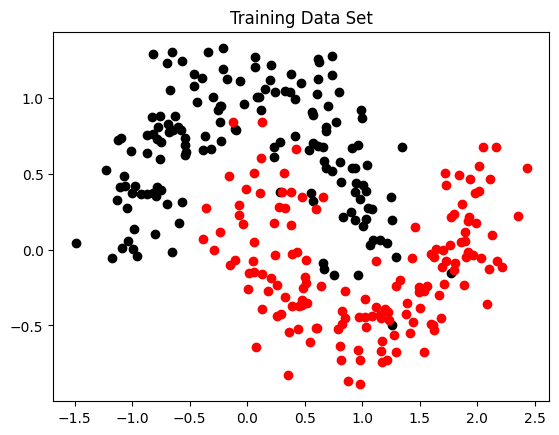

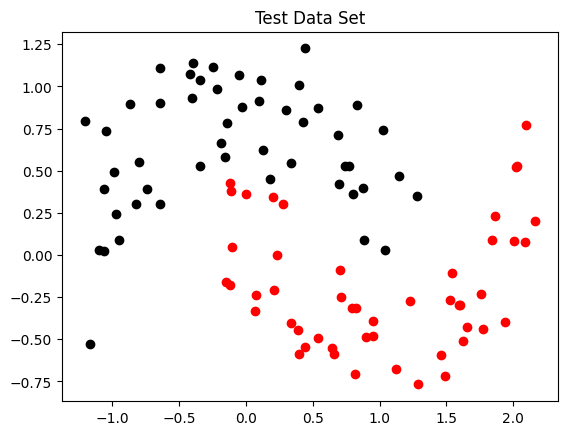

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split

X, y = noisy_moons = datasets.make_moons(n_samples=400, noise=0.2)

X_train, X_test, y_train, y_test =  train_test_split(X, y)

# Visualize the training data set
order_ind = np.argsort(y_train)
Xm1_train = X_train[order_ind[0:150]]
Xm2_train = X_train[order_ind[151:300]]

plt.figure()
plt.scatter(Xm1_train[:,0], Xm1_train[:,1], color='black')
plt.scatter(Xm2_train[:,0], Xm2_train[:,1], color='red')
plt.title("Training Data Set")
plt.show()

# Visualize the test data set
order_ind = np.argsort(y_test)
Xm1_test = X_test[order_ind[0:50]]
Xm2_test = X_test[order_ind[51:100]]

plt.figure()
plt.scatter(Xm1_test[:,0], Xm1_test[:,1], color='black')
plt.scatter(Xm2_test[:,0], Xm2_test[:,1], color='red')
plt.title("Test Data Set")
plt.show()

1. Finish the implementation of the DNN class:
  (a) `init` method defines the model structure: create linear layers for the model and the number of node of each layer should match the `layer_list`.
  (b) `forward` method performs the forward-propagation process of DNN: pass the input `x` through each layer in the model sequentially and apply activation function.
2. Train and evaluate a DNN using the class written in Question 3.1. Start with an example structure (8, 4, 1) and then try different DNN structures. For alternative choices, you can use only one hidden layer or many more layers. You can also use different activation functions as long as you end up with a single node binary classifier. Try also different optimizers, training learning rate, and loss functions. Which one works best? Try, observe, and discuss!
3. For the best combination (structure, activation function, optimizer, learning rate, and loss function) you managed to find in Question 3.2, investigate the impact of training epochs on DNN performance. Observe the difference between training and test set loss and accuracy. Interpret your results. What does a big difference between training and test set performance mean? Note: if the training and test accuracy are the same, increase the `noise` from 0.2 to a higher value.
4. Try other advanced types of neural networks.

In [6]:
# Implementation of DNN
class DNN(nn.Module):
    def __init__(self, input_dim, layer_list, activation='relu'):
        super(DNN, self).__init__()

        # Create linear layers
        layers = []
        layers.append(nn.Linear(input_dim, layer_list[0]))

        for i in range(1, len(layer_list)):
            layers.append(nn.Linear(layer_list[i-1], layer_list[i]))

        self.layers = nn.ModuleList(layers)
        self.activation = activation

    def apply_activation(self, x):
        # Apply different activation functions
        if self.activation == 'relu':
            return F.relu(x)
        elif self.activation == 'tanh':
            return torch.tanh(x)
        elif self.activation == 'sigmoid':
            return torch.sigmoid(x)
        else:
            return x

    def forward(self, input):
        output = input

        for i, layer in enumerate(self.layers):
            output = layer(output)

            # Apply activation to hidden layers only
            if i < len(self.layers) - 1:
                output = self.apply_activation(output)

        return output

In [5]:
# Convert numpy arrays to torch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

def train_and_evaluate(layer_list, activation='relu', optimizer_name='adam', lr=0.01, loss_name='bce_logits', epochs=1000):
    # Create model
    model = DNN(input_dim=2, layer_list=layer_list, activation=activation)

    # Define loss function
    if loss_name == 'bce_logits':
        loss_fn = nn.BCEWithLogitsLoss()
    elif loss_name == 'bce':
        loss_fn = nn.BCELoss()
    else:
        raise ValueError("loss_name must be 'bce_logits' or 'bce'")

    # Define optimizer
    if optimizer_name == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    else:
        raise ValueError("optimizer_name must be 'adam' or 'sgd'")

    # Training loop
    for epoch in range(epochs):
        model.train()

        # Forward pass
        logits = model(X_train_tensor)
        if loss_name == 'bce_logits':
            loss = loss_fn(logits, y_train_tensor)
        elif loss_name == 'bce':
            probs = torch.sigmoid(logits)
            loss = loss_fn(probs, y_train_tensor)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Evaluation
    model.eval()

    with torch.no_grad():
        # Training accuracy
        train_logits = model(X_train_tensor)
        train_probs = torch.sigmoid(train_logits)
        train_preds = (train_probs >= 0.5).float()
        train_acc = (train_preds == y_train_tensor).float().mean().item()

        # Test accuracy
        test_logits = model(X_test_tensor)
        test_probs = torch.sigmoid(test_logits)
        test_preds = (test_probs >= 0.5).float()
        test_acc = (test_preds == y_test_tensor).float().mean().item()

    return model, loss.item(), train_acc, test_acc


In [6]:
experiments = [
    # Baseline
    ['Baseline', [8, 4, 1], 'relu', 'adam', 0.01, 'bce_logits'],

    # Different DNN structure
    ['One hidden layer', [8, 1], 'relu', 'adam', 0.01, 'bce_logits'],
    ['Larger network', [16, 8, 1], 'relu', 'adam', 0.01, 'bce_logits'],
    ['Deeper network', [16, 8, 4, 1], 'relu', 'adam', 0.01, 'bce_logits'],

    # Different activation
    ['Tanh activation', [8, 4, 1], 'tanh', 'adam', 0.01, 'bce_logits'],
    ['Sigmoid activation', [8, 4, 1], 'sigmoid', 'adam', 0.01, 'bce_logits'],

    # Different optimizer
    ['SGD optimizer', [8, 4, 1], 'relu', 'sgd', 0.01, 'bce_logits'],

    # Different learning rate
    ['Smaller learning rate', [8, 4, 1], 'relu', 'adam', 0.001, 'bce_logits'],
    ['Larger learning rate', [8, 4, 1], 'relu', 'adam', 0.05, 'bce_logits'],

    # Different loss function
    ['BCELoss', [8, 4, 1], 'relu', 'adam', 0.01, 'bce']
]

results = []

for name, layer_list, activation, optimizer_name, lr, loss_name in experiments:
    model, loss, train_acc, test_acc = train_and_evaluate(
        layer_list=layer_list,
        activation=activation,
        optimizer_name=optimizer_name,
        lr=lr,
        loss_name=loss_name,
        epochs=1000
    )

    results.append([
        name,
        layer_list,
        activation,
        optimizer_name,
        lr,
        loss_name,
        loss,
        train_acc,
        test_acc,
        model
    ])

for result in results:
    print(result[:-1]) 


ImportError: cannot import name 'DiagnosticOptions' from 'torch.onnx._internal.exporter' (e:\Anaconda\envs\soml\lib\site-packages\torch\onnx\_internal\exporter\__init__.py)

Best model:
Name: Smaller learning rate
Structure: [8, 4, 1]
Activation: relu
Optimizer: adam
Learning rate: 0.001
Final loss: 0.19696342945098877
Training accuracy: 0.9200000166893005
Test accuracy: 0.9800000190734863


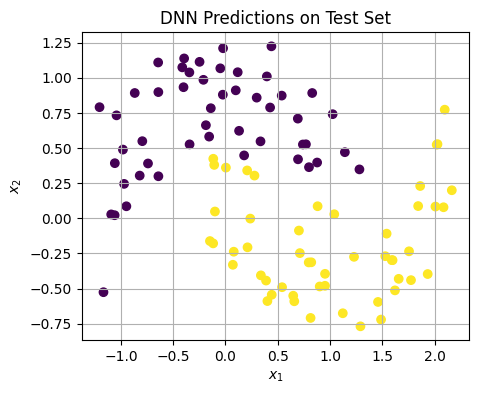

In [154]:
best_result = max(results, key=lambda x: x[8])

best_name = best_result[0]
best_layer_list = best_result[1]
best_activation = best_result[2]
best_optimizer_name = best_result[3]
best_lr = best_result[4]
best_loss_name = best_result[5]
best_loss = best_result[6]
best_train_acc = best_result[7]
best_test_acc = best_result[8]
best_model = best_result[9]

print("Best model:")
print("Name:", best_name)
print("Structure:", best_layer_list)
print("Activation:", best_activation)
print("Optimizer:", best_optimizer_name)
print("Learning rate:", best_lr)
print("Final loss:", best_loss)
print("Training accuracy:", best_train_acc)
print("Test accuracy:", best_test_acc)

best_model.eval()

with torch.no_grad():
    test_logits = best_model(X_test_tensor)
    test_probs = torch.sigmoid(test_logits)
    test_preds = (test_probs >= 0.5).float().numpy().reshape(-1)

plt.figure(figsize=(5, 4))
plt.scatter(X_test[:, 0], X_test[:, 1], c=test_preds)
plt.title('DNN Predictions on Test Set')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.grid(True)
plt.show()

#### Answer to Q3.2:

A DNN classifier was trained and evaluated using the class implemented in Question 3.1. The input dimension is 2, since each sample in the two-moon dataset has two features. The output layer has one node because this is a binary classification problem.

The baseline model used the structure \([8,4,1]\), ReLU activation, Adam optimizer, learning rate \(0.01\), and `BCEWithLogitsLoss`. This model achieved a training accuracy of about \(95.7%\) and a test accuracy of about \(96.0%\).

Several alternative settings were tested. First, different DNN structures were compared. The one-hidden-layer model \([8,1]\) achieved a test accuracy of about \(97.0%\), while the larger model \([16,8,1]\) and the deeper model \([16,8,4,1]\) both achieved about \(95.0%\) test accuracy. In this experiment, increasing the network size did not improve the test accuracy.

Different activation functions were also tested while keeping the structure fixed as \([8,4,1]\). ReLU and sigmoid achieved similar test accuracy, while tanh gave a slightly lower test accuracy in this run.

The optimizer also had a clear effect. Adam performed much better than SGD. With SGD, the test accuracy dropped to about \(89.0%\), suggesting that SGD did not converge as effectively under the chosen learning rate and number of epochs.

Different learning rates were tested using the baseline structure. The best result was obtained with the smaller learning rate \(0.001\). This model achieved a training accuracy of about \(92.0%\) and a test accuracy of about \(98.0%\). Although its training accuracy was lower than some other models, its test accuracy was the highest, which suggests better generalization to unseen data.

For the loss function, `BCEWithLogitsLoss` and `BCELoss` were compared. Both are suitable for binary classification, but `BCEWithLogitsLoss` is generally preferred because it combines sigmoid and binary cross entropy in a more numerically stable way.

Overall, the best model in this experiment was the \([8,4,1]\) network with ReLU activation, Adam optimizer, learning rate \(0.001\), and `BCEWithLogitsLoss`. It achieved the highest test accuracy of about \(98.0%\). The prediction result of the best model on the test set is shown in the plot.

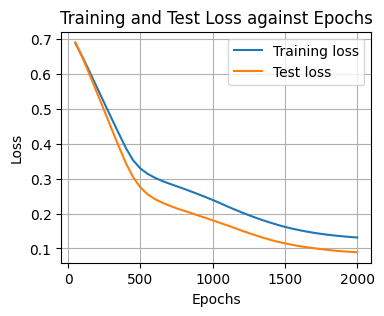

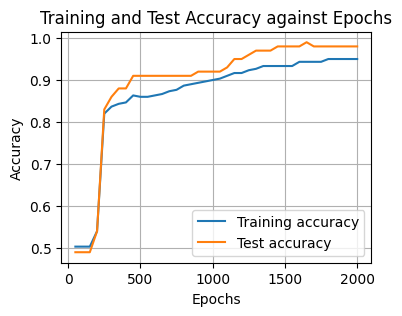

Final training loss: 0.1312250792980194
Final test loss: 0.08901800215244293
Final training accuracy: 0.949999988079071
Final test accuracy: 0.9800000190734863


In [157]:
def train_with_epoch_tracking(layer_list, activation='relu', optimizer_name='adam',
                              lr=0.001, loss_name='bce_logits', epochs=2000):
    # Create model
    model = DNN(input_dim=2, layer_list=layer_list, activation=activation)

    # Define loss function
    if loss_name == 'bce_logits':
        loss_fn = nn.BCEWithLogitsLoss()
    elif loss_name == 'bce':
        loss_fn = nn.BCELoss()
    else:
        raise ValueError("loss_name must be 'bce_logits' or 'bce'")

    # Define optimizer
    if optimizer_name == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    else:
        raise ValueError("optimizer_name must be 'adam' or 'sgd'")

    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []
    epoch_list = []

    for epoch in range(1, epochs + 1):
        model.train()

        # Forward pass
        train_logits = model(X_train_tensor)

        if loss_name == 'bce_logits':
            train_loss = loss_fn(train_logits, y_train_tensor)
        else:
            train_probs = torch.sigmoid(train_logits)
            train_loss = loss_fn(train_probs, y_train_tensor)

        # Backward pass
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        # Evaluate every 50 epochs
        if epoch % 50 == 0:
            model.eval()

            with torch.no_grad():
                # Training performance
                train_logits = model(X_train_tensor)
                train_probs = torch.sigmoid(train_logits)
                train_preds = (train_probs >= 0.5).float()
                train_acc = (train_preds == y_train_tensor).float().mean().item()

                if loss_name == 'bce_logits':
                    train_loss_eval = loss_fn(train_logits, y_train_tensor).item()
                else:
                    train_loss_eval = loss_fn(train_probs, y_train_tensor).item()

                # Test performance
                test_logits = model(X_test_tensor)
                test_probs = torch.sigmoid(test_logits)
                test_preds = (test_probs >= 0.5).float()
                test_acc = (test_preds == y_test_tensor).float().mean().item()

                if loss_name == 'bce_logits':
                    test_loss_eval = loss_fn(test_logits, y_test_tensor).item()
                else:
                    test_loss_eval = loss_fn(test_probs, y_test_tensor).item()

            epoch_list.append(epoch)
            train_losses.append(train_loss_eval)
            test_losses.append(test_loss_eval)
            train_accuracies.append(train_acc)
            test_accuracies.append(test_acc)

    return model, epoch_list, train_losses, test_losses, train_accuracies, test_accuracies

best_model, epoch_list, train_losses, test_losses, train_accuracies, test_accuracies = train_with_epoch_tracking(
    layer_list=[8, 4, 1],
    activation='relu',
    optimizer_name='adam',
    lr=0.001,
    loss_name='bce_logits',
    epochs=2000
)

# loss against epochs
plt.figure(figsize=(4, 3))
plt.plot(epoch_list, train_losses, label='Training loss')
plt.plot(epoch_list, test_losses, label='Test loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Test Loss against Epochs')
plt.legend()
plt.grid(True)
plt.show()

# accuracy against eopchs
plt.figure(figsize=(4, 3))
plt.plot(epoch_list, train_accuracies, label='Training accuracy')
plt.plot(epoch_list, test_accuracies, label='Test accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Test Accuracy against Epochs')
plt.legend()
plt.grid(True)
plt.show()

print("Final training loss:", train_losses[-1])
print("Final test loss:", test_losses[-1])
print("Final training accuracy:", train_accuracies[-1])
print("Final test accuracy:", test_accuracies[-1])

#### Answer to Q3.3:

Using the best combination found in Question 3.2, the DNN structure was fixed as \([8,4,1]\), with ReLU activation, Adam optimizer, learning rate \(0.001\), and `BCEWithLogitsLoss`. The model was trained for different numbers of epochs, and both loss and accuracy were recorded on the training and test sets.

From the loss plot, both the training loss and test loss decrease as the number of epochs increases. The training loss decreases from about \(0.69\) to \(0.131\), while the test loss decreases from about \(0.69\) to \(0.089\). This shows that the model is learning the classification boundary better over time.

From the accuracy plot, both training and test accuracy increase quickly in the early epochs and then improve more gradually. The final training accuracy is about \(0.950\), while the final test accuracy is about \(0.980\). The test accuracy is slightly higher than the training accuracy in this run. This may be because the test set is relatively small or slightly easier than the training set.

There is no clear sign of overfitting in this experiment. If overfitting occurred, the training loss would continue to decrease while the test loss started to increase, or the training accuracy would become much higher than the test accuracy. In this result, the training and test curves both improve together.

A large difference between training and test performance usually means poor generalization. For example, if the training accuracy is high but the test accuracy is much lower, the model may have fitted the training data too closely, including noise or random patterns. This is known as overfitting.

Overall, increasing the number of epochs improved both training and test performance in this experiment, and the best model generalized well to the test set.

Advanced DNN model:
Final loss: 0.2911354899406433
Training accuracy: 0.8933333158493042
Test accuracy: 0.9399999976158142


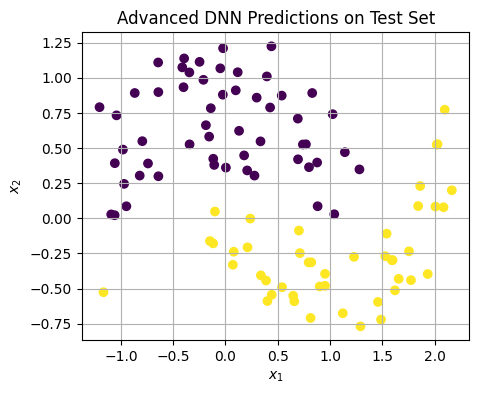

In [159]:
# Advanced DNN
class AdvancedDNN(nn.Module):
    def __init__(self, input_dim, layer_list, activation='relu', dropout_rate=0.2):
        super(AdvancedDNN, self).__init__()

        # Create linear layers
        self.layers = nn.ModuleList()
        self.batch_norms = nn.ModuleList()

        self.layers.append(nn.Linear(input_dim, layer_list[0]))
        self.batch_norms.append(nn.BatchNorm1d(layer_list[0]))

        for i in range(1, len(layer_list)):
            self.layers.append(nn.Linear(layer_list[i-1], layer_list[i]))

            # Add batch normalization only for hidden layers
            if i < len(layer_list) - 1:
                self.batch_norms.append(nn.BatchNorm1d(layer_list[i]))

        self.activation = activation
        self.dropout = nn.Dropout(dropout_rate)

    def apply_activation(self, x):
        # Apply activation function
        if self.activation == 'relu':
            return F.relu(x)
        elif self.activation == 'tanh':
            return torch.tanh(x)
        elif self.activation == 'sigmoid':
            return torch.sigmoid(x)
        else:
            return x

    def forward(self, input):
        output = input

        for i, layer in enumerate(self.layers):
            output = layer(output)

            # Apply batch normalization, activation and dropout to hidden layers only
            if i < len(self.layers) - 1:
                output = self.batch_norms[i](output)
                output = self.apply_activation(output)
                output = self.dropout(output)

        return output
    
def train_and_evaluate_advanced(layer_list, activation='relu', optimizer_name='adam',
                                lr=0.001, loss_name='bce_logits',
                                dropout_rate=0.2, epochs=1000):
    # Create model
    model = AdvancedDNN(
        input_dim=2,
        layer_list=layer_list,
        activation=activation,
        dropout_rate=dropout_rate
    )

    # Define loss function
    if loss_name == 'bce_logits':
        loss_fn = nn.BCEWithLogitsLoss()
    elif loss_name == 'bce':
        loss_fn = nn.BCELoss()
    else:
        raise ValueError("loss_name must be 'bce_logits' or 'bce'")

    # Define optimizer
    if optimizer_name == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    else:
        raise ValueError("optimizer_name must be 'adam' or 'sgd'")

    # Training loop
    for epoch in range(epochs):
        model.train()

        logits = model(X_train_tensor)

        if loss_name == 'bce_logits':
            loss = loss_fn(logits, y_train_tensor)
        else:
            probs = torch.sigmoid(logits)
            loss = loss_fn(probs, y_train_tensor)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Evaluation
    model.eval()

    with torch.no_grad():
        train_logits = model(X_train_tensor)
        train_probs = torch.sigmoid(train_logits)
        train_preds = (train_probs >= 0.5).float()
        train_acc = (train_preds == y_train_tensor).float().mean().item()

        test_logits = model(X_test_tensor)
        test_probs = torch.sigmoid(test_logits)
        test_preds = (test_probs >= 0.5).float()
        test_acc = (test_preds == y_test_tensor).float().mean().item()

    return model, loss.item(), train_acc, test_acc

advanced_model, advanced_loss, advanced_train_acc, advanced_test_acc = train_and_evaluate_advanced(
    layer_list=[8, 4, 1],
    activation='relu',
    optimizer_name='adam',
    lr=0.001,
    loss_name='bce_logits',
    dropout_rate=0.2,
    epochs=1000
)

print("Advanced DNN model:")
print("Final loss:", advanced_loss)
print("Training accuracy:", advanced_train_acc)
print("Test accuracy:", advanced_test_acc)

advanced_model.eval()

with torch.no_grad():
    test_logits = advanced_model(X_test_tensor)
    test_probs = torch.sigmoid(test_logits)
    test_preds = (test_probs >= 0.5).float().numpy().reshape(-1)

plt.figure(figsize=(5, 4))
plt.scatter(X_test[:, 0], X_test[:, 1], c=test_preds)
plt.title('Advanced DNN Predictions on Test Set')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.grid(True)
plt.show()

#### Answer to Q3.4:

An advanced neural network was also tested by adding batch normalization and dropout to the fully connected DNN. The structure was still based on \([8,4,1]\), but batch normalization was applied after the hidden linear layers, and dropout was used to reduce overfitting.

The Advanced DNN achieved a training accuracy of about \(0.893\) and a test accuracy of about \(0.940\). The prediction result on the test set is shown in the plot above.

Compared with the best ordinary DNN from Question 3.2, which achieved a test accuracy of about \(0.980\), the Advanced DNN did not improve the performance in this experiment. This may be because the two-moon dataset is relatively small and simple, so the ordinary DNN was already able to learn a good nonlinear decision boundary.

In addition, dropout may make training harder for such a small network, because some hidden units are randomly disabled during training. Therefore, although batch normalization and dropout are useful techniques in larger neural networks, they did not give better results for this small two-moon classification task.

## Question 5: Generative Modeling with Convolutional Variational Autoencoders (VAEs) (Marks: 3 + 5 + 7 + 5 = 20 Points)

**Background:**
A Variational Autoencoder (VAE) is a generative model that treats image generation as a reconstruction task through a compressed "bottleneck." Unlike standard Autoencoders that map an input $x$ to a single fixed point $z\in\mathbb{R}^d$ ($d$ is the latent space dimension), a VAE uses a probabilistic approach to ensure the compressed space is continuous and suitable for sampling.

The VAE consists of two neural networks (NNs) named as encoder and decoder:
* The encoder compresses the input image $x$ into a latent representation. Instead of learning a single point $z$, the encoder learns the mean $\mu=(\mu_1,\cdots,\mu_d)\in\mathbb{R}^d$ and variance $\sigma^2=(\sigma^2_1,\cdots,\sigma^2_d)\in\mathbb{R}^d$ of the latent distribution $q(z|x)$. We assume a diagonal Gaussian distribution $\mathcal{N}(\mu,\text{diag}(\sigma^2))$ where each entry of $z$ is independent of each other. The hidden layer feature $z\in\mathbb{R}^d$ is sampled from this distribution.
* The decoder takes the latent vector $z$ and attempts to reconstruct the original input. The output is the reconstructed image $\hat{x}$.

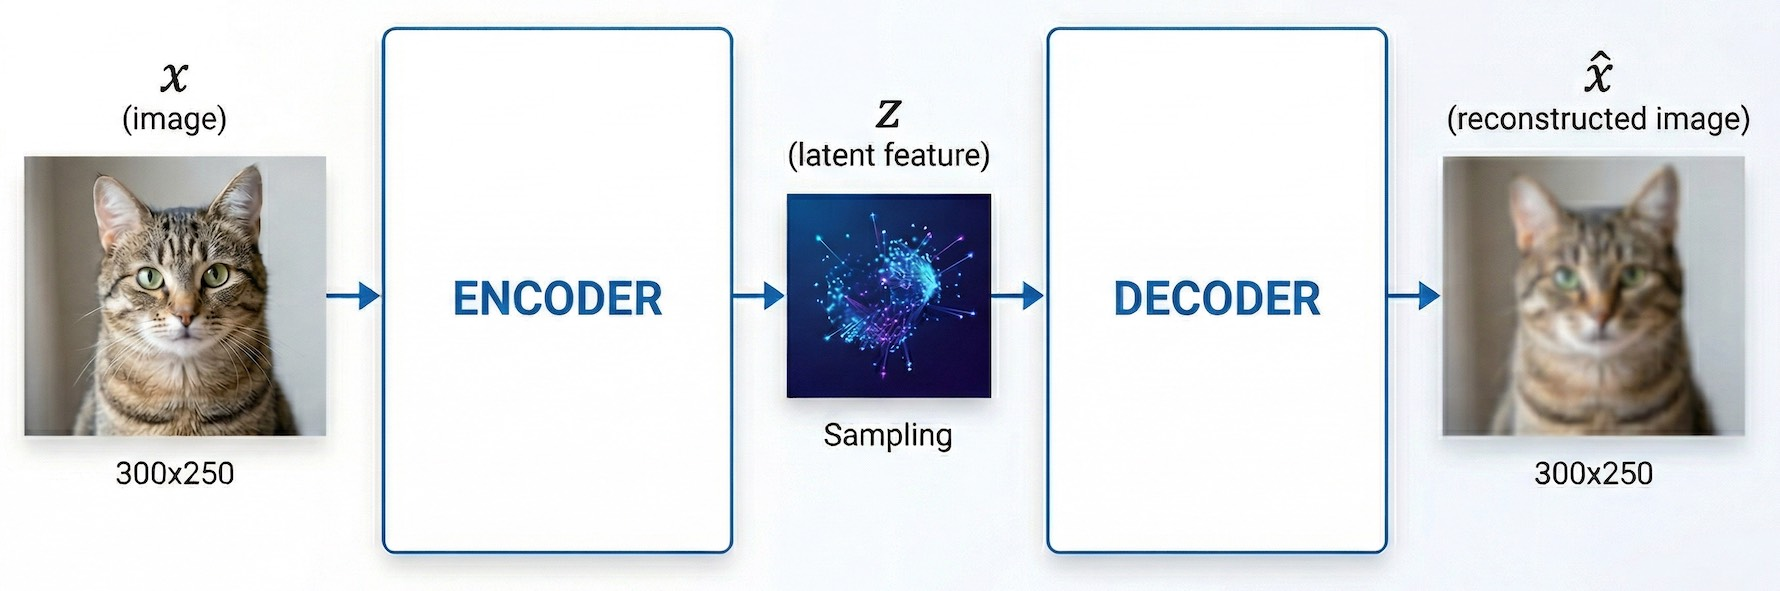

To train the NN-based encoder and decoder, we define the loss function for image reconstructrion. Unlike standard autoencoders that use simple Mean Squared Error (MSE), VAEs are trained by maximizing the Evidence Lower Bound (ELBO), which is equivalent to minimizing the negative ELBO. The loss function consists of two competing terms:
1.  **Reconstruction Loss:** Measures the pixel-wise difference between input $x$ and output $\hat{x}$. We can use MSE (or Binary Cross Entropy) to measure the pixel-wise difference.
2.  **KL Divergence ($D_{KL}$):** Acts as a regularizer. It calculate the distance between the approximated distribution of $z$ (which is a diagonal Gaussian parameterized by the encoder's outputs $\mu$ and $\sigma^2$) and a standard normal distribution $\mathcal{N}(\mathbf{0},\mathbf{I}_d)$.

### Part A: Mathematical Foundation and the Reparameterization Trick (3 Points)
**Questions:**
1. Explain conceptually and algebraically why we cannot use standard back-propagation if we sample $z$ directly as $z\sim\mathcal{N}(\mu, \sigma^2)$ during the training process of a VAE. How does the reparameterization trick $z=\mu+\sigma\odot \epsilon$ solve the problem of using back-propagation? ($\odot$ represents element-wise multiplication and $\epsilon\sim\mathcal{N}(\mathbf{0},\mathbf{I}_d)$)
2. Let's look at a simple toy example. Suppose our encoder outputs a scalar $\mu = 2$ and $\sigma = 1$. We sample a value $\epsilon = 0.5$ from the standard normal distribution $\mathcal{N}(0, 1)$. Our loss function is purely a toy reconstruction loss defined as $L = (z - 5)^2$. Use the reparameterization trick to calculate the gradient of the loss with respect to both $\mu$ and $\sigma$.

#### Answer to Q5 Part A:

If we directly sample z from $z\sim\mathcal{N}(\mu,\sigma^2)$, the sampling operation introduces randomness inside the computational graph. Standard back-propagation requires a differentiable path from the loss back to the model parameters. However, direct sampling does not provide a simple deterministic relationship between $z$ and the encoder outputs $\mu$ and $\sigma$. Therefore, gradients cannot be directly propagated through the random sampling operation.

The reparameterization trick solves this problem by rewriting the sampling process as

$$
z = \mu + \sigma \epsilon, \quad \epsilon\sim\mathcal{N}(\mathbf{0},\mathbf{I}_d)
$$


Here, the randomness is isolated in $\epsilon$, which is independent of $\mu$ and $\sigma$. For a fixed sampled $\epsilon$, z becomes a differentiable function of $\mu$ and $\sigma$, so gradients can be computed using standard back-propagation.

For the toy example, we have

$$
\mu = 2, \quad \sigma = 1, \quad \epsilon = 0.5
$$

Using the reparameterization trick,

$$
z = \mu + \sigma \epsilon = 2 + 1 \times 0.5 = 2.5
$$

$$
\frac{\partial z}{\partial \mu}=1, \quad \frac{\partial z}{\partial \sigma}=\epsilon=0.5
$$


The loss is

$$
L = (z-5)^2 = (2.5-5)^2 = 6.25
$$

The gradient of the loss is

$$
\frac{\partial L}{\partial z} = 2(z-5) = -5
$$

Therefore,

$$
\frac{\partial L}{\partial \mu} = \frac{\partial L}{\partial z} \frac{\partial z}{\partial \mu} = -5 
$$

$$
\frac{\partial L}{\partial \sigma} = \frac{\partial L}{\partial z} \frac{\partial z}{\partial \sigma} = -2.5
$$


### Part B: Designing a Convolutional VAE for CIFAR-10 (5 Points)
**Questions:**
Using PyTorch, implement a `ConvVAE` class designed for the CIFAR-10 dataset (where inputs are 3 channels, 32x32 pixels). To avoid dimension mismatch errors, you can use the following specific architecture:

1. **Encoder:** Three `Conv2d` layers with kernel size 3.
    * Layer 1: 3 input channels $\rightarrow$ 16 output channels (with ReLU).
    * Layer 2: 16 input channels $\rightarrow$ 32 output channels (with ReLU).
    * Layer 3: 32 input channels $\rightarrow$ 64 output channels (with ReLU).
    * Apply a ReLU activation after each convolutional layer.
2. **Latent Mapping:** Flatten the output of the final convolutional layer and map it using two separate `Linear` layers to `mu` and `log_var`. The latent space dimension should be parameterized by an initialization variable `latent_dim`.
3. **Reparameterization:** A `reparameterize` method implementing the trick discussed in Part A.
4. **Decoder:** Map the latent vector back to a tensor of shape `(batch_size, 64, 4, 4)` using a `Linear` layer and ReLU. Then use three `ConvTranspose2d` layers to upsample back to 3x32x32.
    * Use kernel size 3 for all three layers.
    * Layer 1: 64 $\rightarrow$ 32 channels (with ReLU).
    * Layer 2: 32 $\rightarrow$ 16 channels (with ReLU).
    * Layer 3: 16 $\rightarrow$ 3 channels.
    * Apply a `Sigmoid` activation to the final output so pixel values are between 0 and 1.
5. **Forward Pass:** A `forward` method seamlessly connecting the encoder, reparameterization, and decoder.

In [3]:
class ConvVAE(nn.Module):
    def __init__(self, latent_dim):
        super(ConvVAE, self).__init__()

        self.latent_dim = latent_dim

        # Encoder
        self.encoder = nn.Sequential(
            # Input: (batch_size, 3, 32, 32)
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),

            # Output: (batch_size, 16, 16, 16)
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),

            # Output: (batch_size, 32, 8, 8)
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
            # Output: (batch_size, 64, 4, 4)
        )

        # Latent mapping
        self.fc_mu = nn.Linear(64 * 4 * 4, latent_dim)
        self.fc_log_var = nn.Linear(64 * 4 * 4, latent_dim)

        # Decoder input mapping
        self.fc_decode = nn.Linear(latent_dim, 64 * 4 * 4)

        # Decoder
        self.decoder = nn.Sequential(
            # Input: (batch_size, 64, 4, 4)
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),

            # Output: (batch_size, 32, 8, 8)
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),

            # Output: (batch_size, 16, 16, 16)
            nn.ConvTranspose2d(16, 3, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
            # Output: (batch_size, 3, 32, 32)
        )

    def encode(self, x):
        # Pass input through convolutional encoder
        x = self.encoder(x)

        # Flatten convolutional feature maps
        x = x.view(x.size(0), -1)

        # Map to mean and log variance
        mu = self.fc_mu(x)
        log_var = self.fc_log_var(x)

        return mu, log_var

    def reparameterize(self, mu, log_var):
        # Convert log variance to standard deviation
        std = torch.exp(0.5 * log_var)

        # Sample epsilon from standard normal distribution
        eps = torch.randn_like(std)

        # Reparameterization trick
        z = mu + std * eps

        return z

    def decode(self, z):
        # Map latent vector back to feature map
        x = self.fc_decode(z)
        x = F.relu(x)

        # Reshape to convolutional feature map
        x = x.view(x.size(0), 64, 4, 4)

        # Decode to reconstructed image
        x_hat = self.decoder(x)

        return x_hat

    def forward(self, x):
        # Encode input image
        mu, log_var = self.encode(x)

        # Sample latent vector
        z = self.reparameterize(mu, log_var)

        # Decode latent vector
        x_hat = self.decode(z)

        return x_hat, mu, log_var

### Part C: The ELBO Loss and Training Loop (7 Points)

**Questions:**
1. Derive the analytical formula for the KL divergence between a univariate Gaussian approximate posterior $q(z|x) = \mathcal{N}(z;\mu,\text{diag}(\sigma^2))$ and a standard normal prior $p(z) = \mathcal{N}(\mathbf{0},\mathbf{I}_d)$. The definition of KL divergence is given by
$$
D_{KL}(q(z|x)\|p(z)) = \int_{\mathcal{Z}}q(z|x)\log\frac{q(z|x)}{p(z)}dz.
$$
Note: For a multi-variate Gaussian distribution, if the dimensions are independent, the total KL divergence is simply the sum of Kl divergence for each dimension.

2. Write a Python function `vae_loss(recon_x, x, mu, log_var)` that computes the negative ELBO (Reconstruction Loss + KL Divergence). Use MSE with `reduction='sum'` for the reconstruction part.
3. Write a Python function `train(model, train_loader, optimizer, epochs)` that trains the model in a training loop for a given number of epochs, and prints out the training loss for each epoch.
4. Write a Python script that execute the training process:
    * **Data Pre-processing:** Ensure you correctly process the image so they are compatible with your decoder's output.
    * **Training:** Train the model for **25 epochs** using learning rate $0.001$. Set the latent space dimension $d=128$. Print the average loss for each epoch.

#### Answer to Q5 Part C.1:

Since $q(z|x)$ is diagonal, each latent dimension is independent. Therefore, we can first consider the one-dimensional case:

$$
q(z|x)=\mathcal{N}(\mu,\sigma^2),
\qquad
p(z)=\mathcal{N}(0,1)
$$

The KL divergence is defined as

$$
D_{KL}(q(z|x)\|p(z)) = \int q(z|x)\log\frac{q(z|x)}{p(z)}dz
$$

Using the definition of expectation, this can be written as

$$
D_{KL}(q(z|x)\|p(z)) 
= \int \left[ \log q(z|x)-\log p(z) \right] q(z|x) dz
= \mathbb{E}_{q(z|x)} \left[ \log q(z|x)-\log p(z) \right]
$$

For the one-dimensional Gaussian distributions,

$$
\log q(z|x) = -\frac{1}{2}\log(2\pi) -\frac{1}{2}\log(\sigma^2) -\frac{(z-\mu)^2}{2\sigma^2}
$$

$$
\log p(z) = -\frac{1}{2}\log(2\pi) -\frac{z^2}{2}
$$

Therefore,

$$
\log q(z|x)-\log p(z) = -\frac{1}{2}\log(\sigma^2) -\frac{(z-\mu)^2}{2\sigma^2} +\frac{z^2}{2}
$$

Taking expectation with respect to $q(z|x)$, we use

$$
\mathbb{E}_{q(z|x)}[(z-\mu)^2]=\sigma^2
$$

$$
\mathbb{E}_{q(z|x)}[z^2]=\mu^2+\sigma^2
$$

Thus,

$$
D_{KL}(q(z|x)\|p(z))
= -\frac{1}{2}\log(\sigma^2) -\frac{1}{2\sigma^2}\sigma^2 +\frac{1}{2}(\mu^2+\sigma^2)
$$

Therefore, for one dimension,

$$
D_{KL}(q(z|x)\|p(z))
= \frac{1}{2} \left( \mu^2+\sigma^2-\log(\sigma^2)-1 \right)
$$

For the $d$-dimensional diagonal Gaussian case, the total KL divergence is the sum over all latent dimensions:

$$
D_{KL}(q(z|x)\|p(z))
= \frac{1}{2} \sum_{i=1}^{d} \left( \mu_i^2+\sigma_i^2-\log(\sigma_i^2)-1 \right)
$$

Since the implementation uses

$$
\text{log\_var}_i=\log(\sigma_i^2)
$$

we have

$$
\sigma_i^2=\exp(\text{log\_var}_i)
$$

Therefore,

$$
D_{KL}(q(z|x)\|p(z)) 
= \frac{1}{2} \sum_{i=1}^{d} \left( \mu_i^2+\exp(\text{log\_var}_i)-\text{log\_var}_i-1 \right)
$$

Equivalently,

$$
D_{KL}(q(z|x)\|p(z))
= -\frac{1}{2} \sum_{i=1}^{d} \left( 1+\text{log\_var}_i-\mu_i^2-\exp(\text{log\_var}_i) \right)
$$

In [4]:
def vae_loss(recon_x, x, mu, log_var):
    '''
    This function takes the input image and the reconstructed image, calculates and outputs the loss function for vae.
    Inputs:
        recon_x: reconstructed image from the decoder
        x: original image
        mu: mean of the latent distribution
        log_var: log variance of the latent distribution

    Returns:
        loss: the combined reconstruction and KL divergence loss
    '''
    
    # Reconstruction loss
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')

    # KL divergence loss
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

    # Total VAE loss
    loss = recon_loss + kl_loss

    return loss

In [5]:
def train(model, train_loader, lr, epochs, device):
    '''
    This is a general training function that performs a training loop. For a given model, the function iterates over different epochs and the entire dataset, within each iteration the forward-propagation and backward-propagation are executed.
    Inputs:
        model: the ConvVAE model to be trained
        train_loader: DataLoader for the training dataset
        lr: learning rate
        epochs: number of training epochs
        device: device to run the training on (e.g., 'cuda' or 'cpu')
    '''
    # Move model to device
    model = model.to(device)

    # Define optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch_idx, (x, _) in enumerate(train_loader):
            # Move input images to device
            x = x.to(device)

            # Forward pass
            recon_x, mu, log_var = model(x)

            # Compute loss
            loss = vae_loss(recon_x, x, mu, log_var)

            # Back-propagation and parameter update
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # Average loss per sample
        avg_loss = total_loss / len(train_loader.dataset)

        print(f"Epoch [{epoch+1}/{epochs}], Average loss: {avg_loss:.4f}")

In [10]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Data preprocessing
transform = transforms.Compose([
    transforms.ToTensor()
])

# Load CIFAR-10 training dataset
train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

# Create ConvVAE model
latent_dim = 128
model = ConvVAE(latent_dim=latent_dim)

# Train model
train(
    model=model,
    train_loader=train_loader,
    lr=0.001,
    epochs=25,
    device=device
)

HTTPError: HTTP Error 503: Service Unavailable

In [11]:
import torch
print(torch.__version__)

2.2.2


### Part D: Investigating the Compression vs. Performance Trade-off (5 Points)
**Questions:**
The VAE maps high-dimensional CIFAR-10 images (3x32x32 = 3072 dimensions) into a smaller latent representation. The `latent_dim` size controls the "compression rate."
Write a script to investigate how the size of this bottleneck affects the model's ability to reconstruct images.
1. Write a Python function `test()` to evaluate the average reconstruction loss **(only MSE loss)** on the CIFAR-10 **test set**.
2. Instantiate and train three completely separate VAE models using `latent_dim` values of 16, 64, 128, and 256. Train each model for 25 epochs. Use the `test` function to evaluate performance for each trained model. For each trained model, select one image from the test dataset, plot is togehter with its corresponding reconstructed image.
3. Calculate the compression ratio for each latent dimension (the ratio between the size of latent representation $z$ and the input image $x$). Assume an original CIFAR-10 image is 32x32 pixels, 3 channels, where each pixel is an integer value ranging in [0,255]. Assume the latent representation $z$ uses 32-bit floats. Plot the test loss (y-axis) versus the compression ratio (x-axis) using `matplotlib`.
4. Provide a brief discussion on the observed trade-off between the compression rate and reconstruction performance. Why does the loss behave this way?

In [ ]:
def test(model, test_loader, device):
    '''
    Inputs:
        model: the trained ConvVAE model
        test_loader: DataLoader for the test dataset
        device: device to run the testing on (e.g., 'cuda' or 'cpu')

    Returns:
        average_loss: the average loss on the test dataset
    '''
    pass